In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/psrc0514/wifi-identification/wifi_measurements.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/kaggle/input/datasets/psrc0514/wifi-identification/wifi_measurements.csv"
)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.rename(
    columns={"signal_%": "signal_percent"},
    inplace=True
)

numeric_columns = [
    "crowd_density",
    "signal_percent",
    "signal_dbm",
    "ping_ms",
    "link_mbps",
    "dl_mbps",
    "ul_mbps"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [4]:
df["ping_failed"] = (
    df["ping_ms"] >= 999
).astype(int)

df["ping_clean"] = df["ping_ms"].replace(999, np.nan)

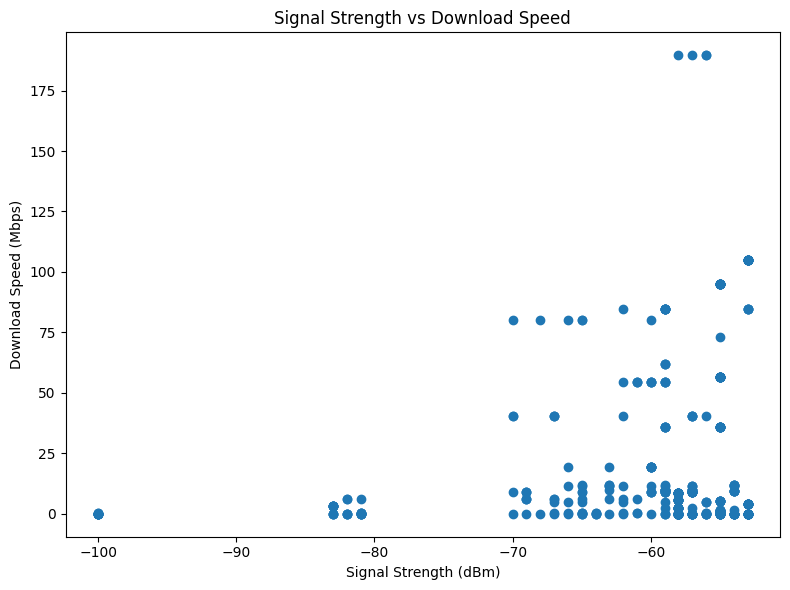

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["signal_dbm"],
    df["dl_mbps"]
)

plt.xlabel("Signal Strength (dBm)")
plt.ylabel("Download Speed (Mbps)")
plt.title("Signal Strength vs Download Speed")

plt.tight_layout()
plt.show()

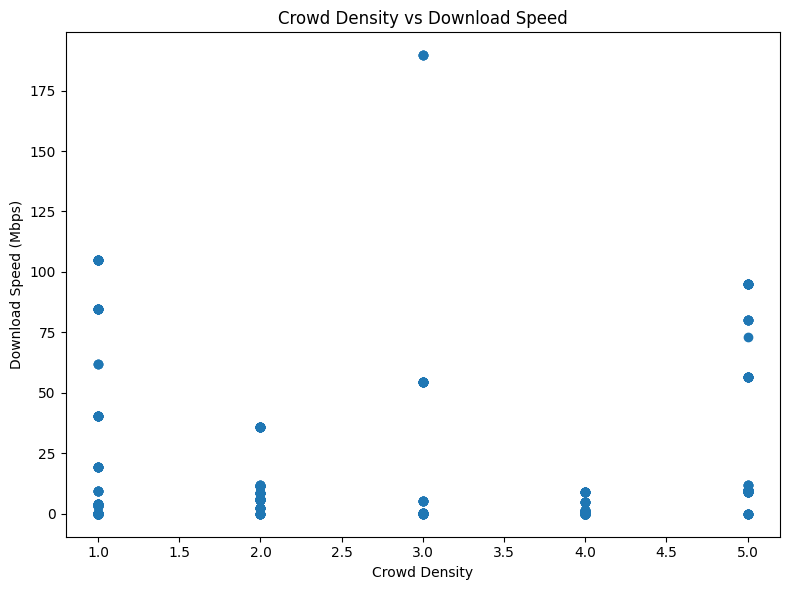

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["crowd_density"],
    df["dl_mbps"]
)

plt.xlabel("Crowd Density")
plt.ylabel("Download Speed (Mbps)")
plt.title("Crowd Density vs Download Speed")

plt.tight_layout()
plt.show()

In [7]:
print(
    df[
        [
            "crowd_density",
            "signal_dbm",
            "ping_clean",
            "dl_mbps",
            "ul_mbps"
        ]
    ].corr()
)

               crowd_density  signal_dbm  ping_clean   dl_mbps   ul_mbps
crowd_density       1.000000    0.260862    0.139665 -0.009209  0.201555
signal_dbm          0.260862    1.000000   -0.092452  0.199416  0.136459
ping_clean          0.139665   -0.092452    1.000000 -0.281447 -0.316068
dl_mbps            -0.009209    0.199416   -0.281447  1.000000  0.755266
ul_mbps             0.201555    0.136459   -0.316068  0.755266  1.000000


In [8]:
location_analysis = (
    df.groupby("location")
      .agg(
          measurements=("location", "size"),
          crowd=("crowd_density", "median"),
          signal=("signal_dbm", "median"),
          download=("dl_mbps", "median"),
          upload=("ul_mbps", "median"),
          ping=("ping_clean", "median"),
          ping_failure=("ping_failed", "mean")
      )
      .reset_index()
)

location_analysis["ping_failure"] *= 100

display(
    location_analysis.sort_values("download")
)

,location,measurements,crowd,signal,download,upload,ping,ping_failure
7,NEW SAC,81,4.0,-58.0,0.00,0.00,110.0,69.135802
8,OPEN ROAD,23,1.0,-83.0,0.00,0.00,NaN,100.000000
6,LIBRARY,20,3.0,-63.5,0.34,0.00,NaN,100.000000
1,CANTEEN,26,2.0,-81.0,0.34,6.52,187.0,84.615385
4,DISANG ROAD,12,1.0,-54.0,4.78,2.81,276.0,0.000000
5,HOSTEL ROOM,10,3.0,-55.0,5.19,8.31,NaN,100.000000
2,CLASSROOM,65,2.0,-58.0,8.67,10.12,NaN,100.000000
3,CORE5 GF,64,5.0,-59.0,9.07,3.25,NaN,100.000000
10,VISITOR ROOM,14,2.0,-58.0,11.51,8.97,NaN,100.000000
11,new sac,20,2.0,-55.0,35.70,10.46,100.0,40.000000


In [9]:
diagnosis = (
    df.groupby(["session", "location"])
      .agg(
          measurements=("location", "size"),
          median_download=("dl_mbps", "median"),
          median_upload=("ul_mbps", "median"),
          median_ping=("ping_clean", "median"),
          ping_failure_rate=("ping_failed", "mean"),
          median_signal=("signal_dbm", "median"),
          median_crowd=("crowd_density", "median")
      )
      .reset_index()
)

diagnosis["ping_failure_rate"] *= 100

In [10]:
display(
    diagnosis.sort_values(
        ["median_download", "ping_failure_rate"],
        ascending=[True, False]
    )
)

,session,location,measurements,median_download,median_upload,median_ping,ping_failure_rate,median_signal,median_crowd
7,MORNING,OPEN ROAD,23,0.00,0.00,NaN,100.000000,-83.0,1.0
6,MORNING,NEW SAC,81,0.00,0.00,110.0,69.135802,-58.0,4.0
5,MORNING,LIBRARY,20,0.34,0.00,NaN,100.000000,-63.5,3.0
9,NIGHT,CANTEEN,11,0.34,6.52,187.0,63.636364,-81.0,1.0
12,NIGHT,DISANG ROAD,12,4.78,2.81,276.0,0.000000,-54.0,1.0
4,MORNING,HOSTEL ROOM,10,5.19,8.31,NaN,100.000000,-55.0,3.0
10,NIGHT,CLASSROOM,37,5.71,4.64,NaN,100.000000,-58.0,2.0
1,MORNING,CANTEEN,15,5.94,17.66,NaN,100.000000,-69.0,2.0
11,NIGHT,CORE5 GF,23,9.06,9.18,NaN,100.000000,-62.0,4.0
3,MORNING,CORE5 GF,41,9.83,3.25,NaN,100.000000,-59.0,5.0


In [11]:
diagnosis["low_speed"] = (
    diagnosis["median_download"] <= 5
)

diagnosis["high_failure"] = (
    diagnosis["ping_failure_rate"] >= 50
)

diagnosis["weak_signal"] = (
    diagnosis["median_signal"] <= -70
)

In [12]:
diagnosis["problem_type"] = np.select(
    [
        diagnosis["weak_signal"] & diagnosis["low_speed"],
        diagnosis["high_failure"] & diagnosis["low_speed"],
        diagnosis["weak_signal"],
        diagnosis["high_failure"],
        diagnosis["low_speed"]
    ],
    [
        "Coverage / Weak Signal",
        "Reliability + Low Speed",
        "Coverage Problem",
        "Reliability Problem",
        "Low Throughput Problem"
    ],
    default="No Major Issue"
)

In [13]:
display(
    diagnosis[
        [
            "session",
            "location",
            "median_download",
            "ping_failure_rate",
            "median_signal",
            "median_crowd",
            "problem_type"
        ]
    ]
)

,session,location,median_download,ping_failure_rate,median_signal,median_crowd,problem_type
0,MORNING,ADMIN BUILDING,54.58,100.000000,-60.0,3.0,Reliability Problem
1,MORNING,CANTEEN,5.94,100.000000,-69.0,2.0,Reliability Problem
2,MORNING,CLASSROOM,56.52,100.000000,-55.0,5.0,Reliability Problem
3,MORNING,CORE5 GF,9.83,100.000000,-59.0,5.0,Reliability Problem
4,MORNING,HOSTEL ROOM,5.19,100.000000,-55.0,3.0,Reliability Problem
5,MORNING,LIBRARY,0.34,100.000000,-63.5,3.0,Reliability + Low Speed
6,MORNING,NEW SAC,0.00,69.135802,-58.0,4.0,Reliability + Low Speed
7,MORNING,OPEN ROAD,0.00,100.000000,-83.0,1.0,Coverage / Weak Signal
8,NIGHT,ADMIN BUILDING,19.20,0.000000,-60.0,1.0,No Major Issue
9,NIGHT,CANTEEN,0.34,63.636364,-81.0,1.0,Coverage / Weak Signal
